In [2]:
"""
Monte Carlo Simulation -- BrightBean Coffee Co. Ltd
5-Year Plant Expansion: NPV Under Uncertainty

Built following the 10-step MCS process:
 1. Model formulation
 2. Risk factor distributions
 3. Initial values & time discretization
 4. Time evolution of risk factors
 5. Correlation structure
 6-9. Random draws, computation, iteration
10. Descriptive statistics
"""

import numpy as np
import pandas as pd
from scipy.stats import norm, t as student_t
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

# =====================================================================
# STEP 1 -- Model formulation
# Target variable : NPV of the plant expansion project
# Risk factors     : revenue growth (g_r), input cost growth (g_c),
#                    UGX/USD depreciation (fx), discount rate (wacc)
#
#   Revenue_t = Revenue_{t-1} * (1 + g_r) * (1 + fx)
#   Cost_t    = Cost_{t-1}    * (1 + g_c) * (1 + fx)
#   FCF_t     = Revenue_t - Cost_t
#   NPV       = sum_t FCF_t / (1 + wacc)^t  -  Initial Investment
# =====================================================================

# =====================================================================
# STEP 2 & 3 -- Distributions, initial values, time discretization
# Time step = 1 year, horizon = 5 years
# =====================================================================
N_ITER, N_YEARS = 10_000, 5

INITIAL_INVESTMENT = 450_000_000   # UGX
REVENUE_0 = 280_000_000            # UGX
COST_0 = 190_000_000               # UGX

REV_MEAN, REV_SD = 0.08, 0.06                  # revenue growth ~ Normal
COST_MEAN, COST_SD, COST_DOF = 0.06, 0.05, 5   # cost growth ~ Student's t (fat tails for commodity shocks)
FX_MEAN, FX_SD = 0.04, 0.07                    # UGX depreciation ~ Normal
WACC_MEAN, WACC_SD = 0.16, 0.015               # discount rate ~ Normal, fixed for project life


In [3]:
# =====================================================================
# STEP 5 -- Correlation between risk factors
# Order: [revenue growth, cost growth, fx]
# WACC is treated as independent of the operating risk factors.
# =====================================================================
corr_matrix = np.array([
    [1.00, 0.30, 0.55],
    [0.30, 1.00, 0.65],
    [0.55, 0.65, 1.00],
])
chol = np.linalg.cholesky(corr_matrix)


def correlated_normals(n_rows, chol_matrix):
    """Draw correlated standard-normal shocks via Cholesky decomposition."""
    z = np.random.standard_normal((n_rows, chol_matrix.shape[0]))
    return z @ chol_matrix.T


def normal_to_t(z, dof):
    """Map a standard-normal draw to a Student's t draw of matching percentile
    (Gaussian copula), standardized to unit variance."""
    u = norm.cdf(z)
    t_draw = student_t.ppf(u, dof)
    return t_draw / np.sqrt(dof / (dof - 2))


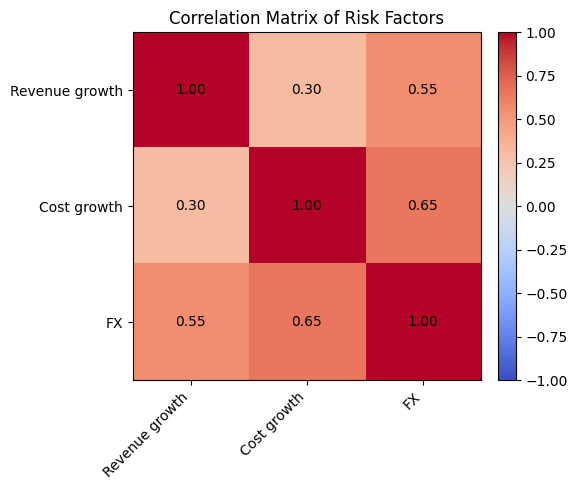

In [6]:
labels = ["Revenue growth", "Cost growth", "FX"]

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}",
                ha="center", va="center", color="black")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_title("Correlation Matrix of Risk Factors")
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [4]:


# =====================================================================
# STEPS 6-9 -- Draw, compute, iterate
# =====================================================================
npvs = np.empty(N_ITER)

for i in range(N_ITER):
    # STEP 4 (WACC is static for the project's life, drawn once per path)
    wacc = max(WACC_MEAN + WACC_SD * np.random.standard_normal(), 0.01)

    revenue, cost = REVENUE_0, COST_0
    fcfs = np.empty(N_YEARS)

    z = correlated_normals(N_YEARS, chol)          # STEP 6: random draws

    for t in range(N_YEARS):
        z_rev, z_cost, z_fx = z[t]

        g_r = REV_MEAN + REV_SD * z_rev             # STEP 7: map draws to risk factor values
        g_c = COST_MEAN + COST_SD * normal_to_t(z_cost, COST_DOF)
        fx = FX_MEAN + FX_SD * z_fx

        revenue *= (1 + g_r) * (1 + fx)
        cost *= (1 + g_c) * (1 + fx)
        fcfs[t] = revenue - cost

    discount_factors = (1 + wacc) ** np.arange(1, N_YEARS + 1)
    npvs[i] = np.sum(fcfs / discount_factors) - INITIAL_INVESTMENT   # STEP 8: target variable

# (STEP 9 is the for-loop itself: 10,000 iterations of steps 6-8)

count    1.000000e+04
mean     9.406196e+06
std      1.228501e+08
min     -3.503151e+08
5%      -1.764459e+08
10%     -1.423170e+08
25%     -7.754709e+07
50%      1.619674e+06
75%      8.566961e+07
90%      1.682704e+08
95%      2.261322e+08
max      5.984795e+08

Probability of negative NPV: 49.48%
5% chance NPV falls below UGX -176,445,928 (this is the 95% VaR threshold)


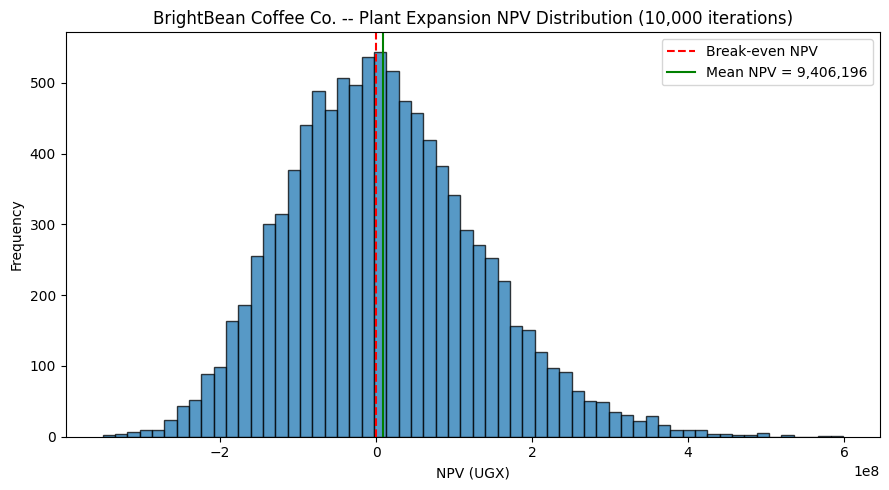

In [5]:
# =====================================================================
# STEP 10 -- Descriptive statistics and analysis
# =====================================================================
results = pd.Series(npvs, name="NPV (UGX)")
summary = results.describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95])
p5 = np.percentile(npvs, 5)
prob_negative = (npvs < 0).mean()

print(summary.to_string())
print(f"\nProbability of negative NPV: {prob_negative:.2%}")
print(f"5% chance NPV falls below UGX {p5:,.0f} (this is the 95% VaR threshold)")

plt.figure(figsize=(9, 5))
plt.hist(npvs, bins=60, edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", label="Break-even NPV")
plt.axvline(results.mean(), color="green", label=f"Mean NPV = {results.mean():,.0f}")
plt.title("BrightBean Coffee Co. -- Plant Expansion NPV Distribution (10,000 iterations)")
plt.xlabel("NPV (UGX)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("npv_distribution.png", dpi=150)
plt.show()